In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [14]:
#Creating a Dataset
X,y = make_classification(
    n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10
)


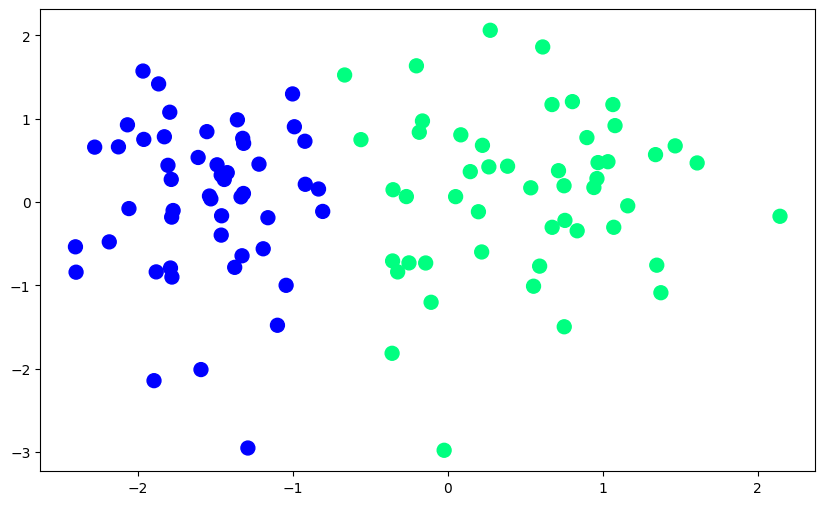

In [15]:
#Visualizing the Dataset
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [9]:
#Creating a Step Function
def step(input):
  if input > 0 :
    return 1
  else :
    return 0

In [20]:
#Applying the Perceptron trick
def perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  W = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    RandomNum = np.random.randint(0,100)
    Y_hat = step(np.dot(W,X[RandomNum]))
    W = W + lr*(y[RandomNum]-Y_hat)*X[RandomNum]

  return W[0],W[1:]

In [ ]:
#Explanation of Perceptron Trick Function :

'''
1. We Add a New Column of Ones in the X For the intercept values
2. We intiliaze the weight matrix with Only ones right now
3. Intiliaze a Learning rate with 0.1
4. Start a loop with 1000 iterations
5. Intiliaze a Random Num variable with Random Number from range 0 to 1000 (to select a random row in our Thousand Rows)
6. Predicting the Output with the Help of Step Function Which Give Output as 0 and 1
7. step function takes input from dot product of W and X which form a equation : W0X0 + W1X1 + W2X2 + ....
8. Finally we update the Weight matrix we intiliaze with Ones Only
9. We return the Intercept and Coefficients
'''

In [21]:
#Intercept and Coef Values
Intercept,Coefficients = perceptron(X,y)
print(f'Intercept : {Intercept}')
print(f'Coefficients : {Coefficients}')

Intercept : 1.0
Coefficients : [1.33272074 0.0593687 ]


(-3.0, 2.0)

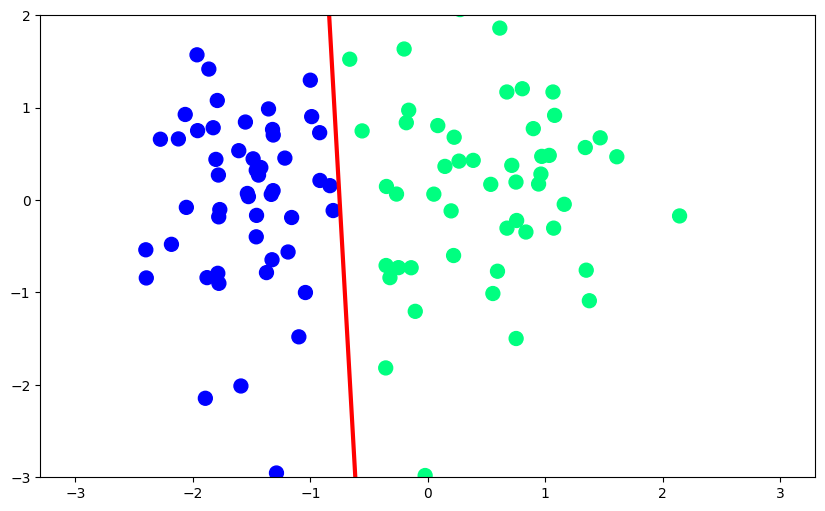

In [22]:
#Creating a Decision Boundary
m = -(Coefficients[0]/Coefficients[1])
b = -(Intercept/Coefficients[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

#Plotting the Boundary
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)